# Predicting Weather with Machine Learning

This notebook demonstrates an end-to-end Data Science pipeline to predict temperature using sensor data (`light`, `humidity`) and time (`hour`).

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Set visualization style
sns.set_theme(style="whitegrid")
%matplotlib inline

## 1. Data Loading
We load the raw dataset directly from the CSV file.

In [2]:
df = pd.read_csv('data/weather_data_ist.csv')
df.head()

,temperature,humidity,light,timestamp
0,26.2,81.0,0,2026-01-01 21:47:49.301000+05:30
1,26.2,81.0,0,2026-01-01 21:42:47.425000+05:30
2,26.2,81.0,0,2026-01-01 21:37:45.690000+05:30
3,26.7,81.0,0,2026-01-01 21:32:44.140000+05:30
4,26.7,80.0,0,2026-01-01 21:27:42.660000+05:30


## 2. Exploratory Data Analysis (EDA)
Let's understand the distribution of our data and the relationships between features.

In [3]:
# Basic Info
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 17464 entries, 0 to 17463
Data columns (total 4 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   temperature  17464 non-null  float64
 1   humidity     17464 non-null  float64
 2   light        17464 non-null  int64  
 3   timestamp    17464 non-null  str    
dtypes: float64(2), int64(1), str(1)
memory usage: 545.9 KB


In [4]:
# Descriptive Statistics
df.describe()

,temperature,humidity,light
count,17464.000000,17464.000000,17464.000000
mean,27.746696,80.086464,1576.157581
std,3.637829,12.105388,1701.386478
min,19.000000,32.000000,0.000000
25%,24.800000,71.000000,0.000000
50%,27.600000,82.000000,0.000000
75%,30.800000,91.000000,3475.000000
max,44.400000,96.000000,4095.000000


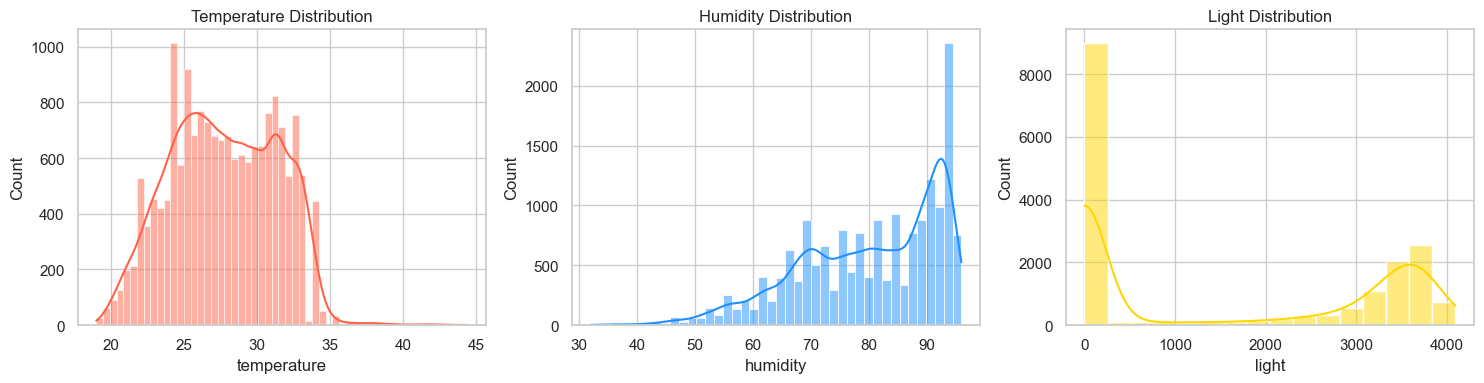

In [5]:
# Histograms
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
sns.histplot(df['temperature'], kde=True, ax=axes[0], color='tomato').set_title('Temperature Distribution')
sns.histplot(df['humidity'], kde=True, ax=axes[1], color='dodgerblue').set_title('Humidity Distribution')
sns.histplot(df['light'], kde=True, ax=axes[2], color='gold').set_title('Light Distribution')
plt.tight_layout()
plt.show()

## 3. Feature Engineering
The `timestamp` column contains valuable time information. We will extract the `hour` of the day and also create a categorical `time_of_day` feature.

In [6]:
# Convert timestamp to datetime
df['timestamp'] = pd.to_datetime(df['timestamp'], format='ISO8601')

# Extract hour
df['hour'] = df['timestamp'].dt.hour

# Create time of day feature
def get_time_of_day(hour):
    if 5 <= hour < 12:
        return 'Morning'
    elif 12 <= hour < 17:
        return 'Afternoon'
    elif 17 <= hour < 21:
        return 'Evening'
    else:
        return 'Night'

df['time_of_day'] = df['hour'].apply(get_time_of_day)

# Plot Average Temperature by Time of Day
plt.figure(figsize=(8, 5))
sns.barplot(x='time_of_day', y='temperature', data=df, order=['Morning', 'Afternoon', 'Evening', 'Night'], palette='viridis')
plt.title('Average Temperature by Time of Day')
plt.show()

ValueError: time data "2025-12-29 20:09:30+05:30" doesn't match format "%Y-%m-%d %H:%M:%S.%f%z". You might want to try:
    - passing `format` if your strings have a consistent format;
    - passing `format='ISO8601'` if your strings are all ISO8601 but not necessarily in exactly the same format;
    - passing `format='mixed'`, and the format will be inferred for each element individually. You might want to use `dayfirst` alongside this.

Let's look at the correlation between numerical features and the target variable (`temperature`).

In [ ]:
# Correlation Heatmap (numerical columns only)
corr = df[['temperature', 'humidity', 'light', 'hour']].corr()
plt.figure(figsize=(6, 5))
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Feature Correlation Heatmap')
plt.show()

## 4. Data Preparation
We prepare our features (X) and target (y), and split them into training and testing sets. We will use a chronological split (70/30) to simulate a real-world time-series forecasting scenario.

In [ ]:
# Select features and target
X = df[['light', 'humidity', 'hour']]
y = df['temperature']

# Chronological split (70/30)
split_index = int(len(df) * 0.7)

X_train = X.iloc[:split_index]
X_test = X.iloc[split_index:]

y_train = y.iloc[:split_index]
y_test = y.iloc[split_index:]

print(f"Training samples: {len(X_train)}")
print(f"Testing samples: {len(X_test)}")

## 5. Model Training & Evaluation
We will compare a simple Linear Regression model with a Random Forest Regressor.

### 5.1 Linear Regression

In [ ]:
lr_model = LinearRegression()
lr_model.fit(X_train, y_train)
lr_preds = lr_model.predict(X_test)

print("Linear Regression Performance:")
print("MAE:", round(mean_absolute_error(y_test, lr_preds), 4))
print("MSE:", round(mean_squared_error(y_test, lr_preds), 4))
print("R2 Score:", round(r2_score(y_test, lr_preds), 4))

### 5.2 Random Forest (with basic Grid Search)

In [ ]:
# To save time in this notebook, we use a small grid
param_grid = {
    'n_estimators': [50, 100],
    'max_depth': [10, None]
}

rf_model = RandomForestRegressor(random_state=42)
grid_search = GridSearchCV(rf_model, param_grid, cv=3, scoring='neg_mean_squared_error', n_jobs=-1)
grid_search.fit(X_train, y_train)

best_rf = grid_search.best_estimator_
rf_preds = best_rf.predict(X_test)

print("Best Parameters:", grid_search.best_params_)
print("\nRandom Forest Performance:")
print("MAE:", round(mean_absolute_error(y_test, rf_preds), 4))
print("MSE:", round(mean_squared_error(y_test, rf_preds), 4))
print("R2 Score:", round(r2_score(y_test, rf_preds), 4))

## 6. Visualizing Results
Let's visualize the performance of our best model (Random Forest).

In [ ]:
# Feature Importance
importance = best_rf.feature_importances_
plt.figure(figsize=(8, 4))
sns.barplot(x=importance, y=X.columns, palette='viridis')
plt.title('Random Forest Feature Importance')
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.show()

In [ ]:
# Actual vs Predicted
plt.figure(figsize=(10, 5))
plt.plot(y_test.values[:100], label='Actual', marker='o')
plt.plot(rf_preds[:100], label='Predicted', marker='x', linestyle='--')
plt.title('Actual vs Predicted Temperature (First 100 Test Samples)')
plt.ylabel('Temperature')
plt.legend()
plt.show()

In [ ]:
# Residuals Distribution
residuals = y_test - rf_preds
plt.figure(figsize=(8, 5))
sns.histplot(residuals, kde=True, color='purple')
plt.title('Distribution of Residuals')
plt.xlabel('Residual Error (Actual - Predicted)')
plt.show()